### Modifications in Data Pipeline (Data Augmentation)

#### What is Augmentation?

- Augmentation is a technique to artificially increase the amount of data by generating new data points from existing data.

**How can we increase the data from existing data?**  
- By making Minor changes such as flips, translations,brigntness,coloring, rotations etc.

**How does it help with training?**  
- This leads to greater diversity of data samples being seen by the network hence decreasing the likelihood of overfitting the model on the training dataset.
- Also it helps in reducing some of the spurious characteristics of the dataset.

#### What different sort of Augmentation strategies we can apply?

Some most common data augmentations are:
* padding
* random rotating
* re-scaling,
* vertical and horizontal flipping
* translation ( image is moved along X, Y direction)
* cropping
* zooming
* darkening & brightening/color modification
* grayscaling
* changing contrast
* adding noise
* random erasing

Methods to apply augmentation in Tensorflow/Keras:

1. Keras provides data augmentation layers like `tf.keras.layers.RandomFlip`, `tf.keras.layers.RandomRotation`, etc. These can be used in a similar way as we used the preprocessing functions.
2. using tf.image methods like `tf.image.stateless_random_flip_up_down`, `tf.image.stateless_random_brightness`
3. using Keras ImageDataGenerator API - It provides quick, out-of-the-box suite of augmentation techniques like standardization, rotation, shifts, flips, brightness change, and many more.

Load Samples

In [ ]:
import os
import glob
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn.metrics as metrics

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(111)

import warnings
warnings.filterwarnings('ignore')

### Functions to Load and Visualize Samples

In [ ]:
# Load Sample: It downloads an image from a given URL, process it, and return it as a NumPy array

def load_sample(output_size=(300, 300)):            # output_size - size to which the image will be resized
    sample = keras.utils.get_file(                  # downloads a file from a given URL
        "sample.jpg",
        "https://t3638486.p.clickup-attachments.com/t3638486/a0a4f633-2963-4e06-acae-2ad1d12eba3e/sample.jpg",
    )
    sample = keras.utils.load_img(sample, target_size=output_size)   # loads the image from the given file path
                                        # target_size=output_size resizes the image to the specified dimensions

    sample = keras.utils.img_to_array(sample)       # converts the loaded image into a NumPy array
    return sample


In [ ]:
# Visualize Sample: It is designed to visualize a augmented images in a grid layout

def show_images(imgs, num_rows, num_cols, scale=2):

    aspect_ratio = imgs[0].shape[0]/imgs[0].shape[1]              # height-to-width ratio of an image
    figsize = (num_cols * scale, num_rows * scale * aspect_ratio) # Defines the size of the figure based on the number
                                                                  # of rows, columns, and aspect ratio

    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize)

    for i in range(num_rows):
        for j in range(num_cols):
            if num_rows != 1:
                # Converts each image tensor to a NumPy array and displays it using imshow
                axes[i][j].imshow(imgs[i * num_cols + j].numpy().astype("uint8"))
                axes[i][j].axes.get_xaxis().set_visible(False)    # Removes axis labels to keep the display clean
                axes[i][j].axes.get_yaxis().set_visible(False)
            else:
                plt.imsave('test.png', imgs[i * num_cols + j].numpy()[0].astype("uint8"))
                axes[j].imshow(imgs[i * num_cols + j].numpy().astype("uint8"))
                axes[j].axes.get_xaxis().set_visible(False)
                axes[j].axes.get_yaxis().set_visible(False)

    plt.subplots_adjust(hspace=0.1, wspace=0)  # hspace reduces vertical spacing between images
                                               # wspace removes horizontal spacing
    return axes

In [ ]:
def apply(img, aug, num_rows=1, num_cols=4, scale=3):

    # apply augmentation multiple times to obtain different samples
    Y = [aug(img) for i in range(num_rows * num_cols)]

    show_images(Y, num_rows, num_cols, scale)      # scale controls the size of the displayed images

#### Basic Augmentation Techniques using `tf.keras.layers.*` and `tf.image`
All these augmentation techniques will only apply if the mode is set to training!

In [ ]:
# Required to reset the mode to training!
tf.keras.backend.clear_session()

##### 1. RandomCrop
This layer will randomly choose a location to crop images down to a target size. The layer will crop all the images in the same batch to the same cropping location.

In [ ]:
sample = load_sample(output_size=(300, 300))
sample

array([[[153., 149., 120.],
        [156., 153., 122.],
        [153., 148., 116.],
        ...,
        [170., 150., 126.],
        [171., 153., 131.],
        [174., 157., 139.]],

       [[157., 153., 124.],
        [160., 155., 125.],
        [159., 153., 121.],
        ...,
        [165., 149., 124.],
        [164., 152., 128.],
        [166., 155., 133.]],

       [[153., 146., 118.],
        [160., 153., 124.],
        [165., 156., 125.],
        ...,
        [155., 140., 117.],
        [154., 142., 116.],
        [161., 151., 124.]],

       ...,

       [[183., 159., 135.],
        [163., 135., 113.],
        [159., 133., 110.],
        ...,
        [173., 159., 124.],
        [175., 158., 114.],
        [194., 173., 130.]],

       [[201., 181., 154.],
        [193., 169., 143.],
        [168., 144., 118.],
        ...,
        [165., 141., 105.],
        [145., 120.,  79.],
        [195., 171., 127.]],

       [[195., 182., 150.],
        [198., 181., 151.],
        [186., 1

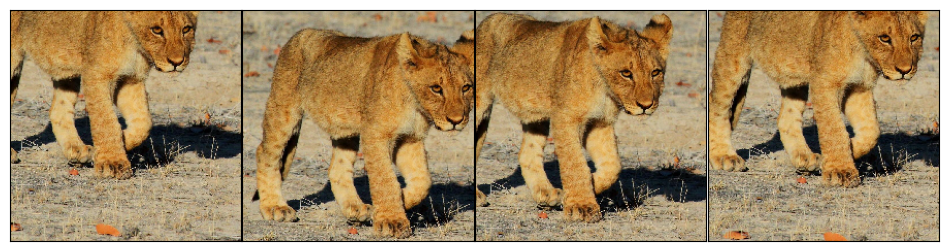

In [ ]:
from keras.layers import RandomCrop

aug_layer = RandomCrop(
    height = 224,
    width = 224,
)

apply(sample, aug_layer)

In [ ]:
# Alternative Implementation using tf.image
random_crop = tf.image.random_crop(value=sample, size=(224, 224, 3))
random_crop

<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[177., 143.,  79.],
        [164., 128.,  66.],
        [194., 156.,  93.],
        ...,
        [185., 163., 126.],
        [184., 160., 124.],
        [187., 161., 124.]],

       [[176., 138.,  73.],
        [178., 143.,  79.],
        [173., 141.,  82.],
        ...,
        [178., 163., 130.],
        [178., 162., 128.],
        [186., 162., 134.]],

       [[189., 149.,  87.],
        [178., 143.,  79.],
        [171., 139.,  80.],
        ...,
        [176., 162., 135.],
        [174., 161., 129.],
        [173., 158., 125.]],

       ...,

       [[141., 123.,  99.],
        [141., 124., 106.],
        [171., 154., 136.],
        ...,
        [197., 180., 154.],
        [190., 175., 146.],
        [187., 176., 146.]],

       [[155., 137., 115.],
        [132., 117.,  96.],
        [122., 107.,  86.],
        ...,
        [199., 180., 150.],
        [198., 181., 151.],
        [197., 182., 149.]],

       [[161., 14

##### 2. RandomTranslation
This layer will apply random translations to each image during training, filling empty space according to fill_mode

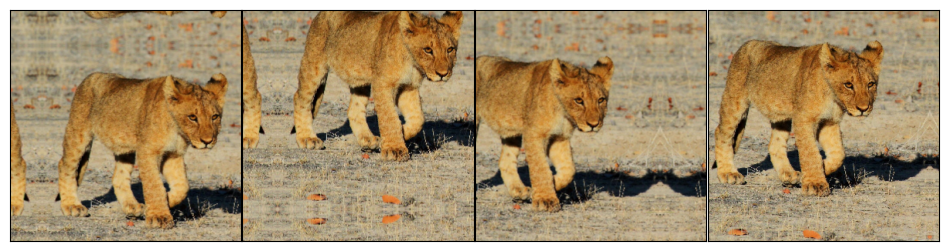

In [ ]:
from keras.layers import RandomTranslation

sample = load_sample(output_size=(300, 300))
aug_layer = RandomTranslation(
    height_factor = (-0.2, 0.3),
    width_factor = (-0.2, 0.3),
)

apply(sample, aug_layer)

In [ ]:
# Alternative Implementation using tf.image
random_shift = tf.keras.preprocessing.image.random_shift(sample, hrg = 0.2, wrg = 0.5)

##### 3. RandomRotation
This layer will apply random rotations to each image, filling out the empty space

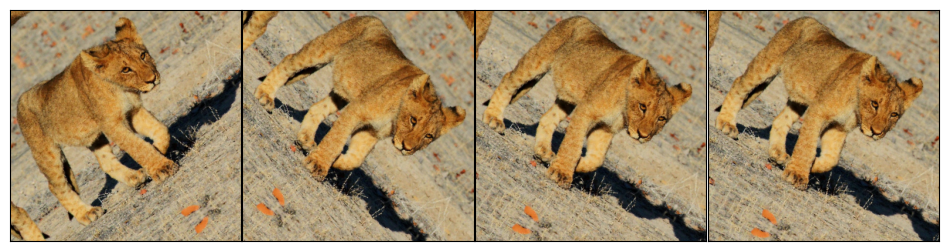

In [ ]:
from keras.layers import RandomRotation

sample = load_sample(output_size=(300, 300))
aug_layer = RandomRotation(
    factor = (-0.2, 0.3),
)
apply(sample, aug_layer)

In [ ]:
# Alternative Implementation using tf.image
random_rotation = tf.keras.preprocessing.image.random_rotation(sample, rg=500, channel_axis=2, row_axis=0, col_axis=1)

##### 4. RandomFlip
This layer will flip the images horizontally and or vertically based on the mode attribute.

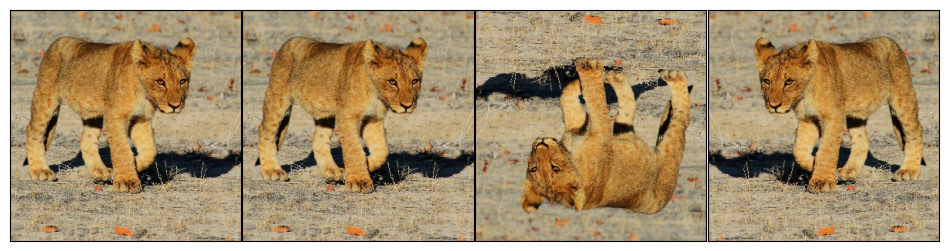

In [ ]:
from keras.layers import RandomFlip

sample = load_sample(output_size=(300, 300))
aug_layer = RandomFlip()

apply(sample, aug_layer)

In [ ]:
# Alternative Implementation using tf.image
randomflip = tf.image.random_flip_left_right(sample, 10)

##### 5. RandomBrightness
This layer will randomly increase/reduce the brightness for the input RGB images.

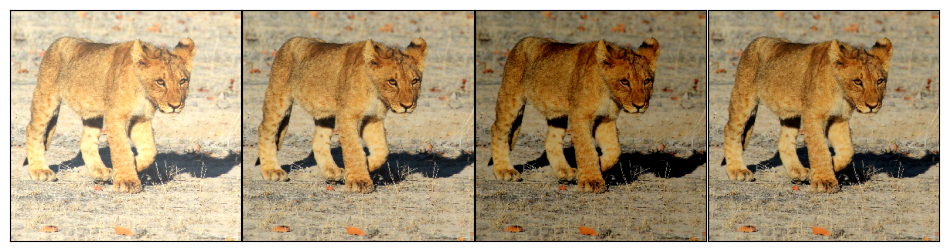

In [ ]:
from tensorflow.keras.layers import RandomBrightness

sample = load_sample(output_size=(300, 300))
aug_layer = RandomBrightness(factor=(-0.2, 0.5))

apply(sample, aug_layer)

In [ ]:
# Alternative Implementation using tf.image
random_bright = tf.image.random_brightness(sample, 100)

##### 6. RandomContrast
This layer will randomly adjust the contrast of an image or images by a random factor. Contrast is adjusted independently for each channel of each image during training

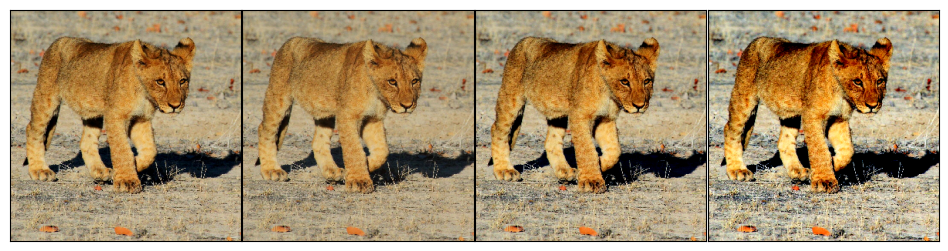

In [ ]:
from keras.layers import RandomContrast

sample = load_sample(output_size=(300, 300))
aug_layer = RandomContrast(factor=(0.5, 0.9))

apply(sample, aug_layer)

In [ ]:
# Alternative Implementation using tf.image
random_contrast = tf.image.random_contrast(sample, 0.5, 10)